# Selecting tiles with significant seasonal snow

This notebook identifies tiles that contain significant seasonal snow coverage and creates a catalog of these tiles which we'll process later.  

1. **Spatial tiling**: Generate a global grid of processing tiles based on the config file
2. **Snow coverage analysis**: Determine which tiles contain seasonal snow using the [Sturm & Liston global seasonal snow classification dataset](https://doi.org/10.1175/JHM-D-21-0070.1)
3. **S1 availability**: Count IW VV items per tile from the MPC STAC GeoParquet index (replaces the old manual geographic removal of Greenland / Canadian Arctic islands)
4. **Output**: Write the versioned tile registry (`tile_data/global_tiles_with_seasonal_snow_v10.geojson`, path from the config's `valid_tiles_geojson_path`) containing tiles with >0.001% seasonal snow pixels plus S1 VV availability columns and a `to_process` flag, ranked by snow coverage percentage

In [1]:
import shapely
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from global_snowmelt_runoff_onset.config import Config, Tile
import easysnowdata
import exactextract
import cartopy.crs as ccrs
import matplotlib.path as mpath
import numpy as np
import matplotlib.patches as mpatches
import collections
import datetime
import pathlib
import adlfs
import geopandas as gpd
import numpy as np
import pandas as pd
import planetary_computer
import pyarrow.dataset as pads
import shapely
from tqdm import tqdm
import matplotlib as mpl
from matplotlib.colors import LogNorm

In [2]:
config = Config('config/global_config_v10.txt')

SAS token is valid until 2026-08-26 19:52 UTC (552.4 hours)
----------------------------------------
Configuration loaded:
config_name = global_config_v10
version = v10
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 84.048
bbox_bottom = -63.4074
expected_grid_shape = 204800, 499998
expected_tile_grid = 100, 245
wy_start = 2015
wy_end = 2025
trailing_buffer_days = 120
low_backscatter_threshold = 0.001
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow_v10.geojson
global_runoff_icechunk_azure_prefix = snowmelt/snowmelt_runoff_onset/global_runoff_onset_v10
inner_chunk_dim = 256
snow_phenology_zarr_store_azure_path = snowmelt/modis_sn

## Global geobox and tiling system

The global geobox defines the entire processing domain, while the tiling system breaks this into manageable chunks:

- **Global extent**: Longitudes from -180° to 180°, latitudes from -63.41°S to 84.05°N
- **Spatial resolution**: ~80m at the equator (0.00072° grid spacing)
- **Tile dimensions**: 2048×2048 pixels per tile
- **Total tiles**: 24,500 tiles (100 rows × 245 columns) covering the global domain
- **Grid extension (2026-07-30)**: `bbox_top` 81.099 → 84.048 and `bbox_bottom` −59.999 → −63.4074 added tile rows 0–1 in the north (to 84.05°N, covering all land on Earth) and 98–99 in the south, and made latitude an exact multiple of the 2048-px tile size. The pixel lattice is unchanged, so v9 tile `(r, c)` is v10 tile `(r + 2, c)`. **Rerunning this notebook is what evaluates the four new rows** — the migrated registry marks them `to_process = False` with a "not yet evaluated" note. See `processing/README.md` (“Grid”).

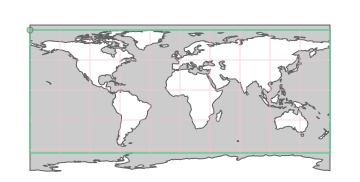

In [3]:
config.global_geobox

In [4]:
config.geobox_tiles

Tiles: 100x245|2048x2048px => 204_800x499_998px

## Tile geometry generation

Create a geodataframe of our global tile scheme to calculate how much seasonal snow is in each tile.

In [5]:
geometries = [shapely.geometry.Polygon(config.geobox_tiles[idx].extent.boundary.coords) for idx in config.geobox_tiles._all_tiles()]
indices = [idx for idx in config.geobox_tiles._all_tiles()]

multi_index = pd.MultiIndex.from_tuples(indices, names=['row', 'col'])

tiles_gdf = gpd.GeoDataFrame({'tile':indices,'geometry': geometries}, index=multi_index, crs=config.geobox_tiles[0,0].crs)
tiles_gdf

tile                                           geometry
row col                                                              
0   0       (0, 0)  POLYGON ((-179.99946 84.04856, -179.99946 82.5...
    1       (0, 1)  POLYGON ((-178.5249 84.04856, -178.5249 82.574...
    2       (0, 2)  POLYGON ((-177.05034 84.04856, -177.05034 82.5...
    3       (0, 3)  POLYGON ((-175.57578 84.04856, -175.57578 82.5...
    4       (0, 4)  POLYGON ((-174.10121 84.04856, -174.10121 82.5...
...            ...                                                ...
99  240  (99, 240)  POLYGON ((173.89529 -61.93302, 173.89529 -63.4...
    241  (99, 241)  POLYGON ((175.36986 -61.93302, 175.36986 -63.4...
    242  (99, 242)  POLYGON ((176.84442 -61.93302, 176.84442 -63.4...
    243  (99, 243)  POLYGON ((178.31898 -61.93302, 178.31898 -63.4...
    244  (99, 244)  POLYGON ((179.79354 -61.93302, 179.79354 -63.4...

[24500 rows x 2 columns]

## Load in sturm seasonal snow classification dataset

In [6]:
sturm_seasonal_snow_classification_da = easysnowdata.remote_sensing.get_seasonal_snow_classification(mask_nodata=False)
sturm_seasonal_snow_classification_da

<xarray.DataArray (y: 64800, x: 129600)> Size: 8GB
dask.array<getitem, shape=(64800, 129600), dtype=uint8, chunksize=(11264, 11264), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 518kB 90.0 90.0 89.99 89.99 ... -89.99 -90.0 -90.0
  * x            (x) float64 1MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes: (12/16)
    Band_1:                    Band 1
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        8
    STATISTICS_MEAN:           6.851992519049
    STATISTICS_MINIMUM:        1
    ...                        ...
    long_name:                 Band 1
    _FillValue:                9
    class_info:                {1: {'name': 'Tundra', 'color': '#a100c8'}, 2:...
    cmap:                      <matplotlib.colors.ListedColormap object at 0x...
    data_citation:             Liston, G. E. and M. Sturm. (2021). Global Sea...
    example_plot:              <function get_seasonal_snow_classification.<lo...

## Get sturm seasonal snow pixel class counts per tile

In [7]:
# Fractional area of each snow class per tile.

# `exact_extract` gives each tile the exact *fractional* pixel coverage per class, so tiles that
# do not align with the classification grid are not biased by whole-pixel rounding.

# - We hand exactextract the *source* the DataArray was opened from rather than the
#   DataArray itself. Reading through the dask-backed DataArray costs one xarray `.sel()`
#   per window and took 98-111 s; letting GDAL do the windowed reads took 11 s. Rechunking
#   the DataArray (2048 or native 512) did not help, so the overhead is the per-window
#   xarray/dask path, not block alignment.
# - `strategy="raster-sequential"` walks the raster block by block and finds the tiles
#   intersecting each block, so every block is read once. The default
#   `"feature-sequential"` re-requests overlapping blocks per tile, which over HTTPS with
#   24,500 tiles is a lot of redundant traffic.


snow_counts_gdf = exactextract.exact_extract(
        sturm_seasonal_snow_classification_da.encoding.get("source", sturm_seasonal_snow_classification_da),
        tiles_gdf.drop(columns=["tile"]),
        ops=["unique", "frac"],
        strategy="raster-sequential",
        include_geom=True,
        output="pandas",
        progress=True,
)
snow_counts_gdf

POLYGON ((-180 -90, 180 -90, 180 -89.6667, -180 -89.6667, -180 -90)): 100%|██████████| 100.0/100 [02:17<00:00,  1.37s/it]                            


,unique,frac,geometry
0,[8],[1.0],"POLYGON ((-179.99946 84.04856, -179.99946 82.5..."
1,[8],[1.0],"POLYGON ((-178.5249 84.04856, -178.5249 82.574..."
2,[8],[1.0],"POLYGON ((-177.05034 84.04856, -177.05034 82.5..."
3,[8],[1.0],"POLYGON ((-175.57578 84.04856, -175.57578 82.5..."
4,[8],[1.0],"POLYGON ((-174.10121 84.04856, -174.10121 82.5..."
...,...,...,...
24495,[8],[1.0],"POLYGON ((173.89529 -61.93302, 173.89529 -63.4..."
24496,[8],[1.0],"POLYGON ((175.36986 -61.93302, 175.36986 -63.4..."
24497,[8],[1.0],"POLYGON ((176.84442 -61.93302, 176.84442 -63.4..."
24498,[8],[1.0],"POLYGON ((178.31898 -61.93302, 178.31898 -63.4..."


## Determine % of pixels in each tile that are seasonal snow

**Classes in [NSIDC dataset user guide](https://nsidc.org/sites/default/files/nsidc-0768-v001-userguide.pdf)**
1. Tundra
2. Boreal Forest
3. Maritime
4. Ephemeral (includes no snow)
5. Prairie
6. Montane Forest
7. Ice (glaciers and ice sheets)
8. Ocean
9. Fill

So we want to calculate % of pixels that are in classes 1,2,3,5,6,7.

In [8]:
valid_snow_classes = [1,2,3,5,6,7]
 
snow_counts_gdf['percent_valid_snow_pixels'] = snow_counts_gdf.apply(
    lambda row: sum(row['frac'][i] for i, val in enumerate(row['unique']) if val in valid_snow_classes), axis=1)*100
snow_counts_gdf

,unique,frac,geometry,percent_valid_snow_pixels
0,[8],[1.0],"POLYGON ((-179.99946 84.04856, -179.99946 82.5...",0.0
1,[8],[1.0],"POLYGON ((-178.5249 84.04856, -178.5249 82.574...",0.0
2,[8],[1.0],"POLYGON ((-177.05034 84.04856, -177.05034 82.5...",0.0
3,[8],[1.0],"POLYGON ((-175.57578 84.04856, -175.57578 82.5...",0.0
4,[8],[1.0],"POLYGON ((-174.10121 84.04856, -174.10121 82.5...",0.0
...,...,...,...,...
24495,[8],[1.0],"POLYGON ((173.89529 -61.93302, 173.89529 -63.4...",0.0
24496,[8],[1.0],"POLYGON ((175.36986 -61.93302, 175.36986 -63.4...",0.0
24497,[8],[1.0],"POLYGON ((176.84442 -61.93302, 176.84442 -63.4...",0.0
24498,[8],[1.0],"POLYGON ((178.31898 -61.93302, 178.31898 -63.4...",0.0


## Merge percent_valid_snow_pixels into tiles_gdf

In [9]:
registry_gdf = tiles_gdf.reset_index().merge(
    snow_counts_gdf[['geometry', 'percent_valid_snow_pixels']], 
    on='geometry', 
    how='left'
).set_index(['row', 'col'])
registry_gdf

tile                                           geometry  \
row col                                                                 
0   0       (0, 0)  POLYGON ((-179.99946 84.04856, -179.99946 82.5...   
    1       (0, 1)  POLYGON ((-178.5249 84.04856, -178.5249 82.574...   
    2       (0, 2)  POLYGON ((-177.05034 84.04856, -177.05034 82.5...   
    3       (0, 3)  POLYGON ((-175.57578 84.04856, -175.57578 82.5...   
    4       (0, 4)  POLYGON ((-174.10121 84.04856, -174.10121 82.5...   
...            ...                                                ...   
99  240  (99, 240)  POLYGON ((173.89529 -61.93302, 173.89529 -63.4...   
    241  (99, 241)  POLYGON ((175.36986 -61.93302, 175.36986 -63.4...   
    242  (99, 242)  POLYGON ((176.84442 -61.93302, 176.84442 -63.4...   
    243  (99, 243)  POLYGON ((178.31898 -61.93302, 178.31898 -63.4...   
    244  (99, 244)  POLYGON ((179.79354 -61.93302, 179.79354 -63.4...   

         percent_valid_snow_pixels  
row col                             
0   0                          0.0  
    1                          0.0  
    2                          0.0  
    3                          0.0  
    4                          0.0  
...                            ...  
99  240                        0.0  
    241                        0.0  
    242                        0.0  
    243                        0.0  
    244                        0.0  

[24500 rows x 3 columns]

<Axes: ylabel='Frequency'>

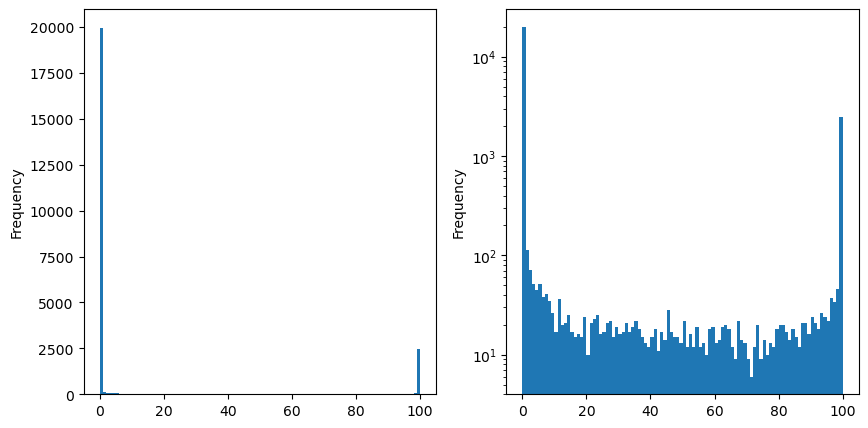

In [10]:
f,axs=plt.subplots(ncols=2,figsize=(10, 5))
registry_gdf["percent_valid_snow_pixels"].plot.hist(bins=100, ax=axs[0])
registry_gdf["percent_valid_snow_pixels"].plot.hist(bins=100, log=True, ax=axs[1])

## Snow threshold: percent of tile

A tile counts as snowy when **> 0.001 %** of its 2048×2048 pixels are seasonal-snow classes (0.001 % ≈ 42 pixels).

Every one of the 24,500 tiles keeps its row all the way to the
GeoJSON; the snow threshold is one of two conditions combined into `to_process` further down,
once the S1 counts are in. Snow-free tiles carry their measured `percent_valid_snow_pixels`, their
S1 counts, and a `tile_notes` string saying they were excluded for lack of snow.

In [11]:
MIN_PERCENT_SEASONAL_SNOW = 0.001   # % of tile pixels; the threshold used by all previous versions

# reported here, applied later — see the to_process cell below
n_snowy = int((registry_gdf["percent_valid_snow_pixels"] > MIN_PERCENT_SEASONAL_SNOW).sum())
print(f"{n_snowy} of {len(registry_gdf)} tiles have > {MIN_PERCENT_SEASONAL_SNOW}% "
      "seasonal-snow pixels (no rows dropped)")

5075 of 24500 tiles have > 0.001% seasonal-snow pixels (no rows dropped)


## S1 VV availability from the catalog (replaces manual region removal)

MPC publishes the full STAC item index as GeoParquet (`abfs://items/sentinel-1-rtc.parquet` on `pcstacitems`, 153 monthly
partitions, token via `planetary_computer.sas.get_token`) so ONE scan yields per-tile × per-year × per-polarization counts for the
whole grid, no API hammering, no pagination. 

Columns: `n_vv_items`, `n_vh_items`, `n_hh_items`, `n_hv_items`,
`n_items_total`, `first_vv_date`, `s1_probe_date`, `tile_notes`; then `to_process = (percent_valid_snow_pixels > 0.001) & (n_vv_items > 40)`.
The pipeline's per-year `no_s1_data` empty markers (v10) remain the runtime safety net, so a
stale probe costs one cheap STAC search per year.

`n_*_items` counts the items whose `sar:polarizations`
list contains that polarization, so a VV+VH item increments `n_vv_items` *and* `n_vh_items`.
They are not a partition of `n_items_total` and summing them double-counts every dual-pol
acquisition. VV and HH are the informative pair: HH-dominated regions (Canadian Arctic
islands) are exactly the ones a VV-based pipeline cannot use, and `n_vh_items` /
`n_hv_items` are along for the ride as the companion channels.


In [12]:
POLARIZATIONS = ["VV", "VH", "HH", "HV"]

token = planetary_computer.sas.get_token("pcstacitems", "items").token
fs = adlfs.AzureBlobFileSystem("pcstacitems", sas_token=token)

# MPC republishes the newest partitions cumulatively — part-0140 exists as 2026-06-01 -> 06-07,
# -> 06-14, -> 06-21 ... — so an item landing in those overlaps sits in up to 8 files. Keep only
# the newest file per part number, which leaves one non-overlapping file per month. Without this
# every recent acquisition is counted several times (measured 2026-07-29: +18% items overall).
partitions = collections.defaultdict(list)
for path in fs.ls("items/sentinel-1-rtc.parquet"):
    if path.endswith(".parquet"):
        part, start, end = pathlib.Path(path).stem.split("_")   # part-NNNN_<start>_<end>
        partitions[part].append((end, start, path))
newest = sorted((start, end, path) for group in partitions.values()
                for end, start, path in [max(group)])
print(f"{sum(len(g) for g in partitions.values())} partition files -> {len(newest)} after "
      "dropping cumulative re-publications")
overlapping = [b[2] for a, b in zip(newest, newest[1:]) if b[0] < a[1]]
if overlapping:
    print(f"WARNING: {len(overlapping)} partitions still overlap in time; items inside an "
          "overlap are counted more than once — check MPC's partitioning scheme")

dataset = pads.dataset([path for _, _, path in newest], filesystem=fs, format="parquet")

# every tile in the grid is probed, snowy or not — to_process is derived further down
tile_geoms = shapely.STRtree(registry_gdf.geometry.values)

n_pol = {pol: np.zeros(len(registry_gdf), dtype=np.int64) for pol in POLARIZATIONS}
n_total = np.zeros(len(registry_gdf), dtype=np.int64)
first_vv = np.full(len(registry_gdf), None, dtype=object)
unexpected_pols = collections.Counter()

# Intersect each item's FOOTPRINT (the `geometry` column), not its bbox. An S1 IW footprint is a
# rotated parallelogram whose bbox reaches well outside it, so a bbox test credits tiles the
# acquisition never covered — worst case measured was tile (9,244) with 416 bbox "hits" against
# 2 real ones, +17% VV items globally. Footprint counts reproduce a STAC API `intersects` search
# exactly.
cols = ["geometry", "datetime", "sar:polarizations"]
for frag in tqdm(list(dataset.get_fragments()), desc="scanning monthly partitions"):
    tbl = frag.to_table(columns=cols)
    if tbl.num_rows == 0:
        continue
    dts = tbl["datetime"].to_pylist()
    # de-duplicate each item's token list once here, so a repeated token in the catalog
    # could never count the same item twice for the same polarization
    pols = [tuple(dict.fromkeys(p)) if p else ()
            for p in tbl["sar:polarizations"].to_pylist()]
    footprints = shapely.from_wkb(tbl["geometry"].to_pylist())
    hits = tile_geoms.query(footprints, predicate="intersects")  # (2, n) item_idx, tile_idx
    for item_i, tile_i in hits.T:
        n_total[tile_i] += 1
        for pol in pols[item_i]:
            counts = n_pol.get(pol)
            if counts is None:
                unexpected_pols[pol] += 1
            else:
                counts[tile_i] += 1
        if "VV" in pols[item_i]:
            d = dts[item_i]
            if first_vv[tile_i] is None or d < first_vv[tile_i]:
                first_vv[tile_i] = d

if unexpected_pols:
    print(f"polarization tokens outside {POLARIZATIONS}: {dict(unexpected_pols)}")

# Each item is counted once per polarization it carries, so a VV+VH item lands in BOTH
# n_vv_items and n_vh_items. The four polarization columns are therefore NOT a partition of
# n_items_total (which counts each item once) and must not be summed to recover it.
for pol in POLARIZATIONS:
    registry_gdf[f"n_{pol.lower()}_items"] = n_pol[pol]
registry_gdf["n_items_total"] = n_total
registry_gdf["first_vv_date"] = [d.date().isoformat() if d else None for d in first_vv]
registry_gdf["s1_probe_date"] = datetime.date.today().isoformat()
n_pol_cols = [f"n_{pol.lower()}_items" for pol in POLARIZATIONS]
print("tiles with >0 items, by polarization:")
print(registry_gdf[n_pol_cols].gt(0).sum().to_string())
print("\nitem counts summed over tiles (tiles overlap, so items are counted per tile):")
print(registry_gdf[n_pol_cols + ["n_items_total"]].sum().to_string())

153 partition files -> 142 after dropping cumulative re-publications


scanning monthly partitions: 100%|██████████| 142/142 [05:46<00:00,  2.44s/it]

tiles with >0 items, by polarization:
n_vv_items    13365
n_vh_items    13307
n_hh_items     5292
n_hv_items     4850

item counts summed over tiles (tiles overlap, so items are counted per tile):
n_vv_items       18163328
n_vh_items       17570947
n_hh_items        2137748
n_hv_items        1710740
n_items_total    20301717


Text(0.5, 0.98, 'Sentinel-1 RTC item counts per tile, by polarization')

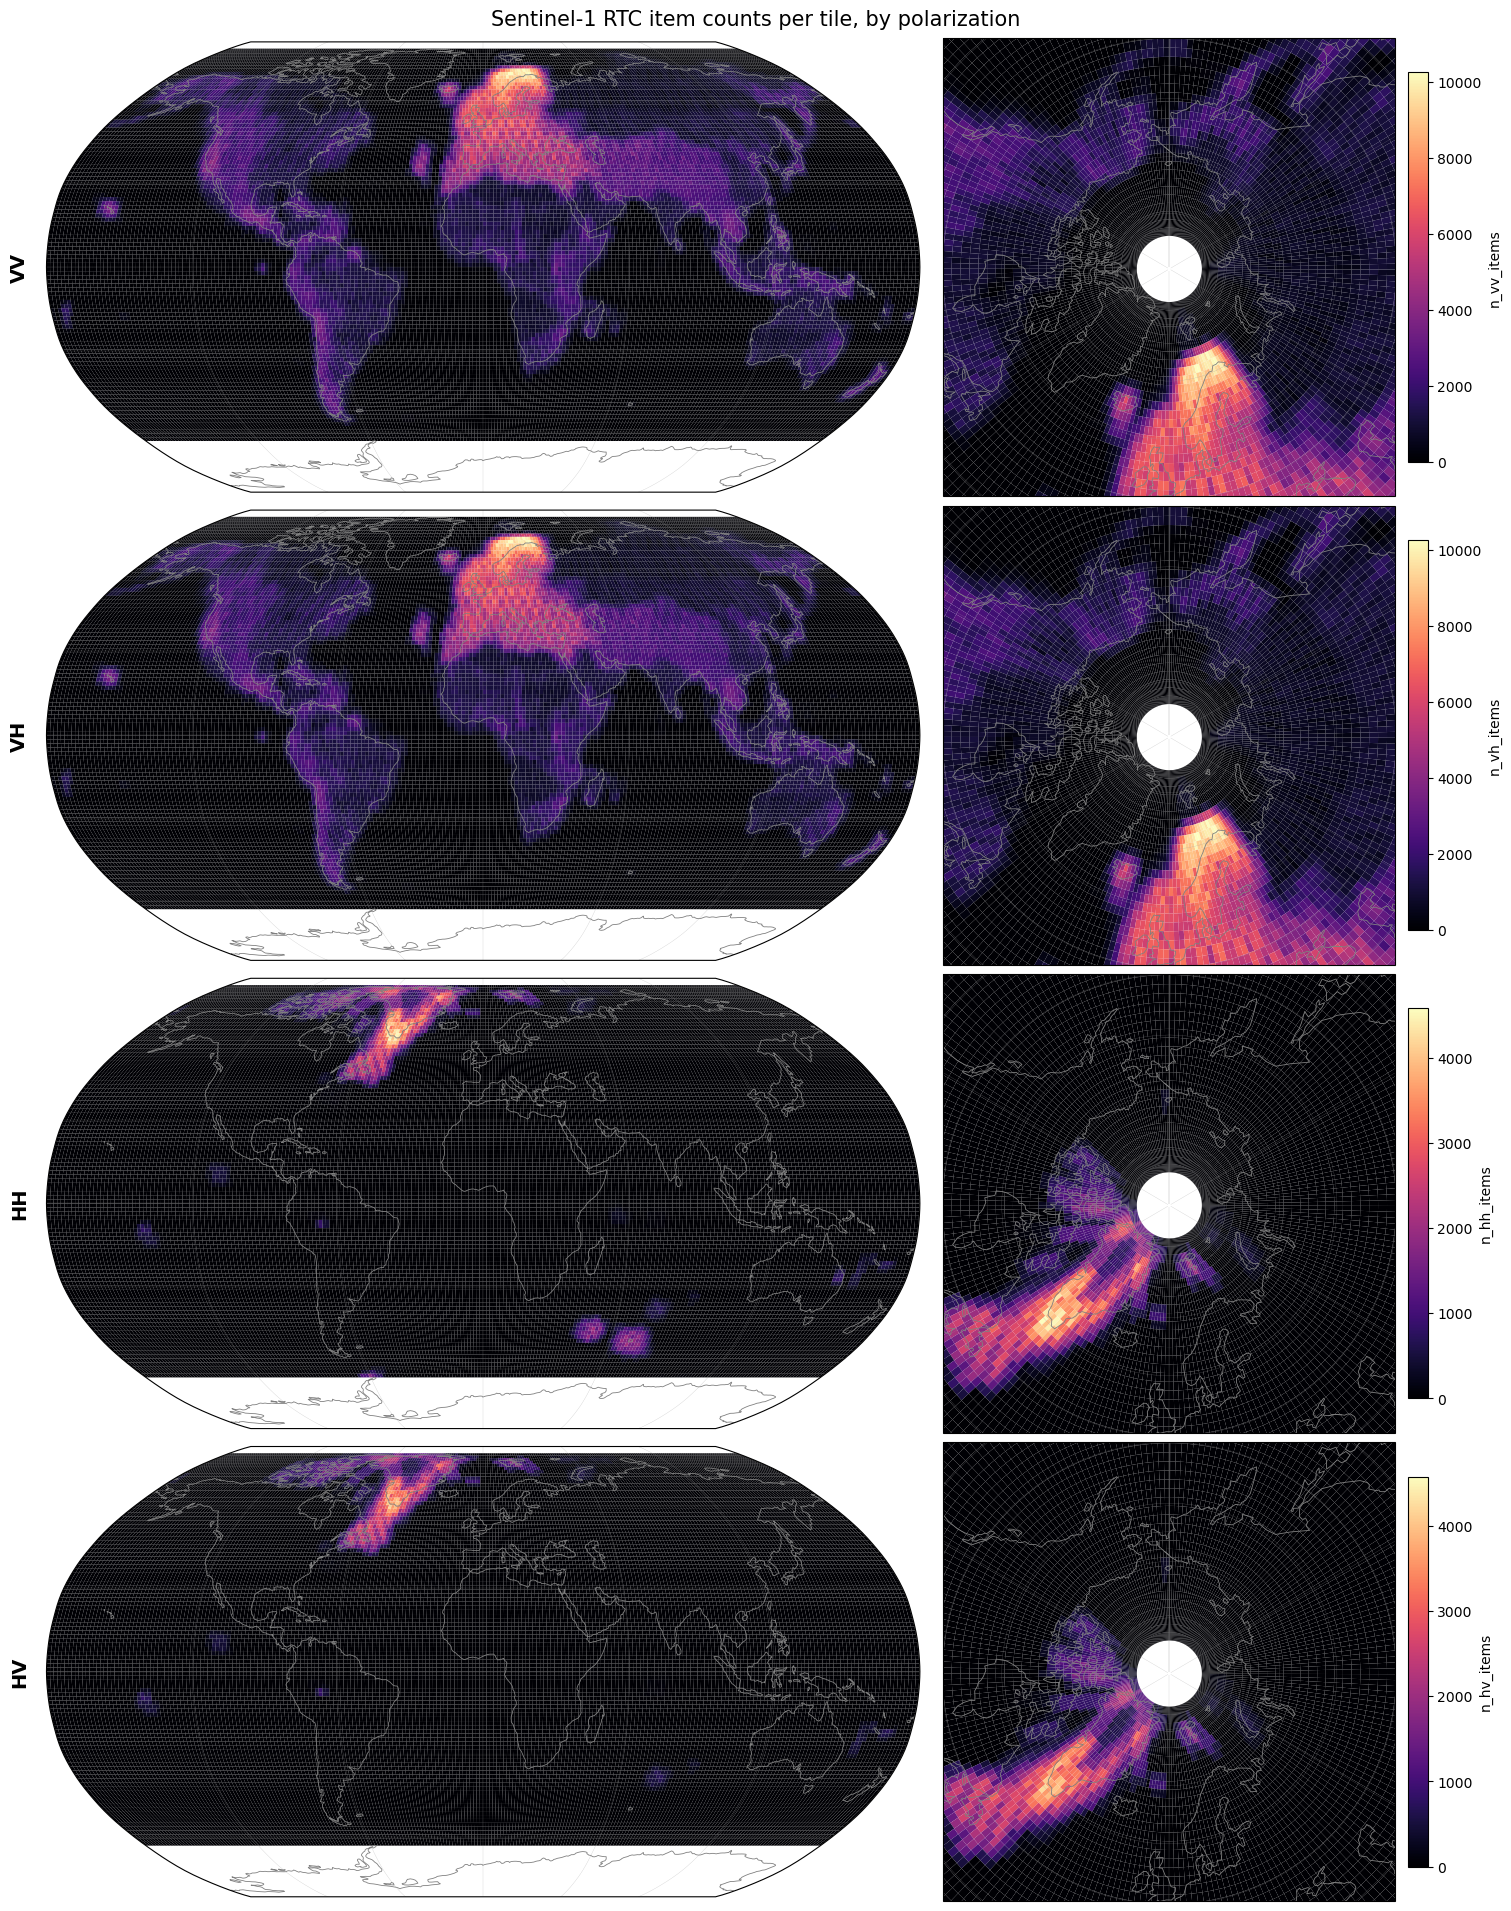

In [13]:
POLARIZATION_ROWS = ["VV", "VH", "HH", "HV"]
CMAP = "magma"

vmax_VV = registry_gdf[["n_vv_items", "n_vh_items"]].max().max()
vmax_HH = registry_gdf[["n_hh_items", "n_hv_items"]].max().max()

# tile corners alone project to straight chords, leaving wedge artifacts near the pole
plot_gdf = registry_gdf.assign(geometry=registry_gdf.geometry.segmentize(0.25))

fig = plt.figure(figsize=(15, 19), layout="constrained")
gs = fig.add_gridspec(len(POLARIZATION_ROWS), 2, width_ratios=[1.9, 1])

for row, pol in enumerate(POLARIZATION_ROWS):
    column = f"n_{pol.lower()}_items"
    vmax = vmax_VV if pol in ("VV", "VH") else vmax_HH
    axs = []
    for col, proj in enumerate((ccrs.Robinson(), ccrs.NorthPolarStereo())):
        ax = fig.add_subplot(gs[row, col], projection=proj)
        if col == 0:
            ax.set_global()
        else:
            ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
        plot_gdf.plot(ax=ax, column=column, cmap=CMAP, vmin=0, vmax=vmax,
                      transform=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.6, color="0.5")
        ax.gridlines(linewidth=0.2, color="0.6", alpha=0.6)
        axs.append(ax)
    axs[0].text(-0.02, 0.5, pol, transform=axs[0].transAxes, rotation=90,
                va="center", ha="right", fontsize=14, fontweight="bold")
    sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(vmin=0, vmax=vmax))
    fig.colorbar(sm, ax=axs, shrink=0.85, pad=0.01, label=column)

fig.suptitle("Sentinel-1 RTC item counts per tile, by polarization", fontsize=15)

Text(0.5, 0.98, 'Sentinel-1 RTC item counts per tile, by polarization')

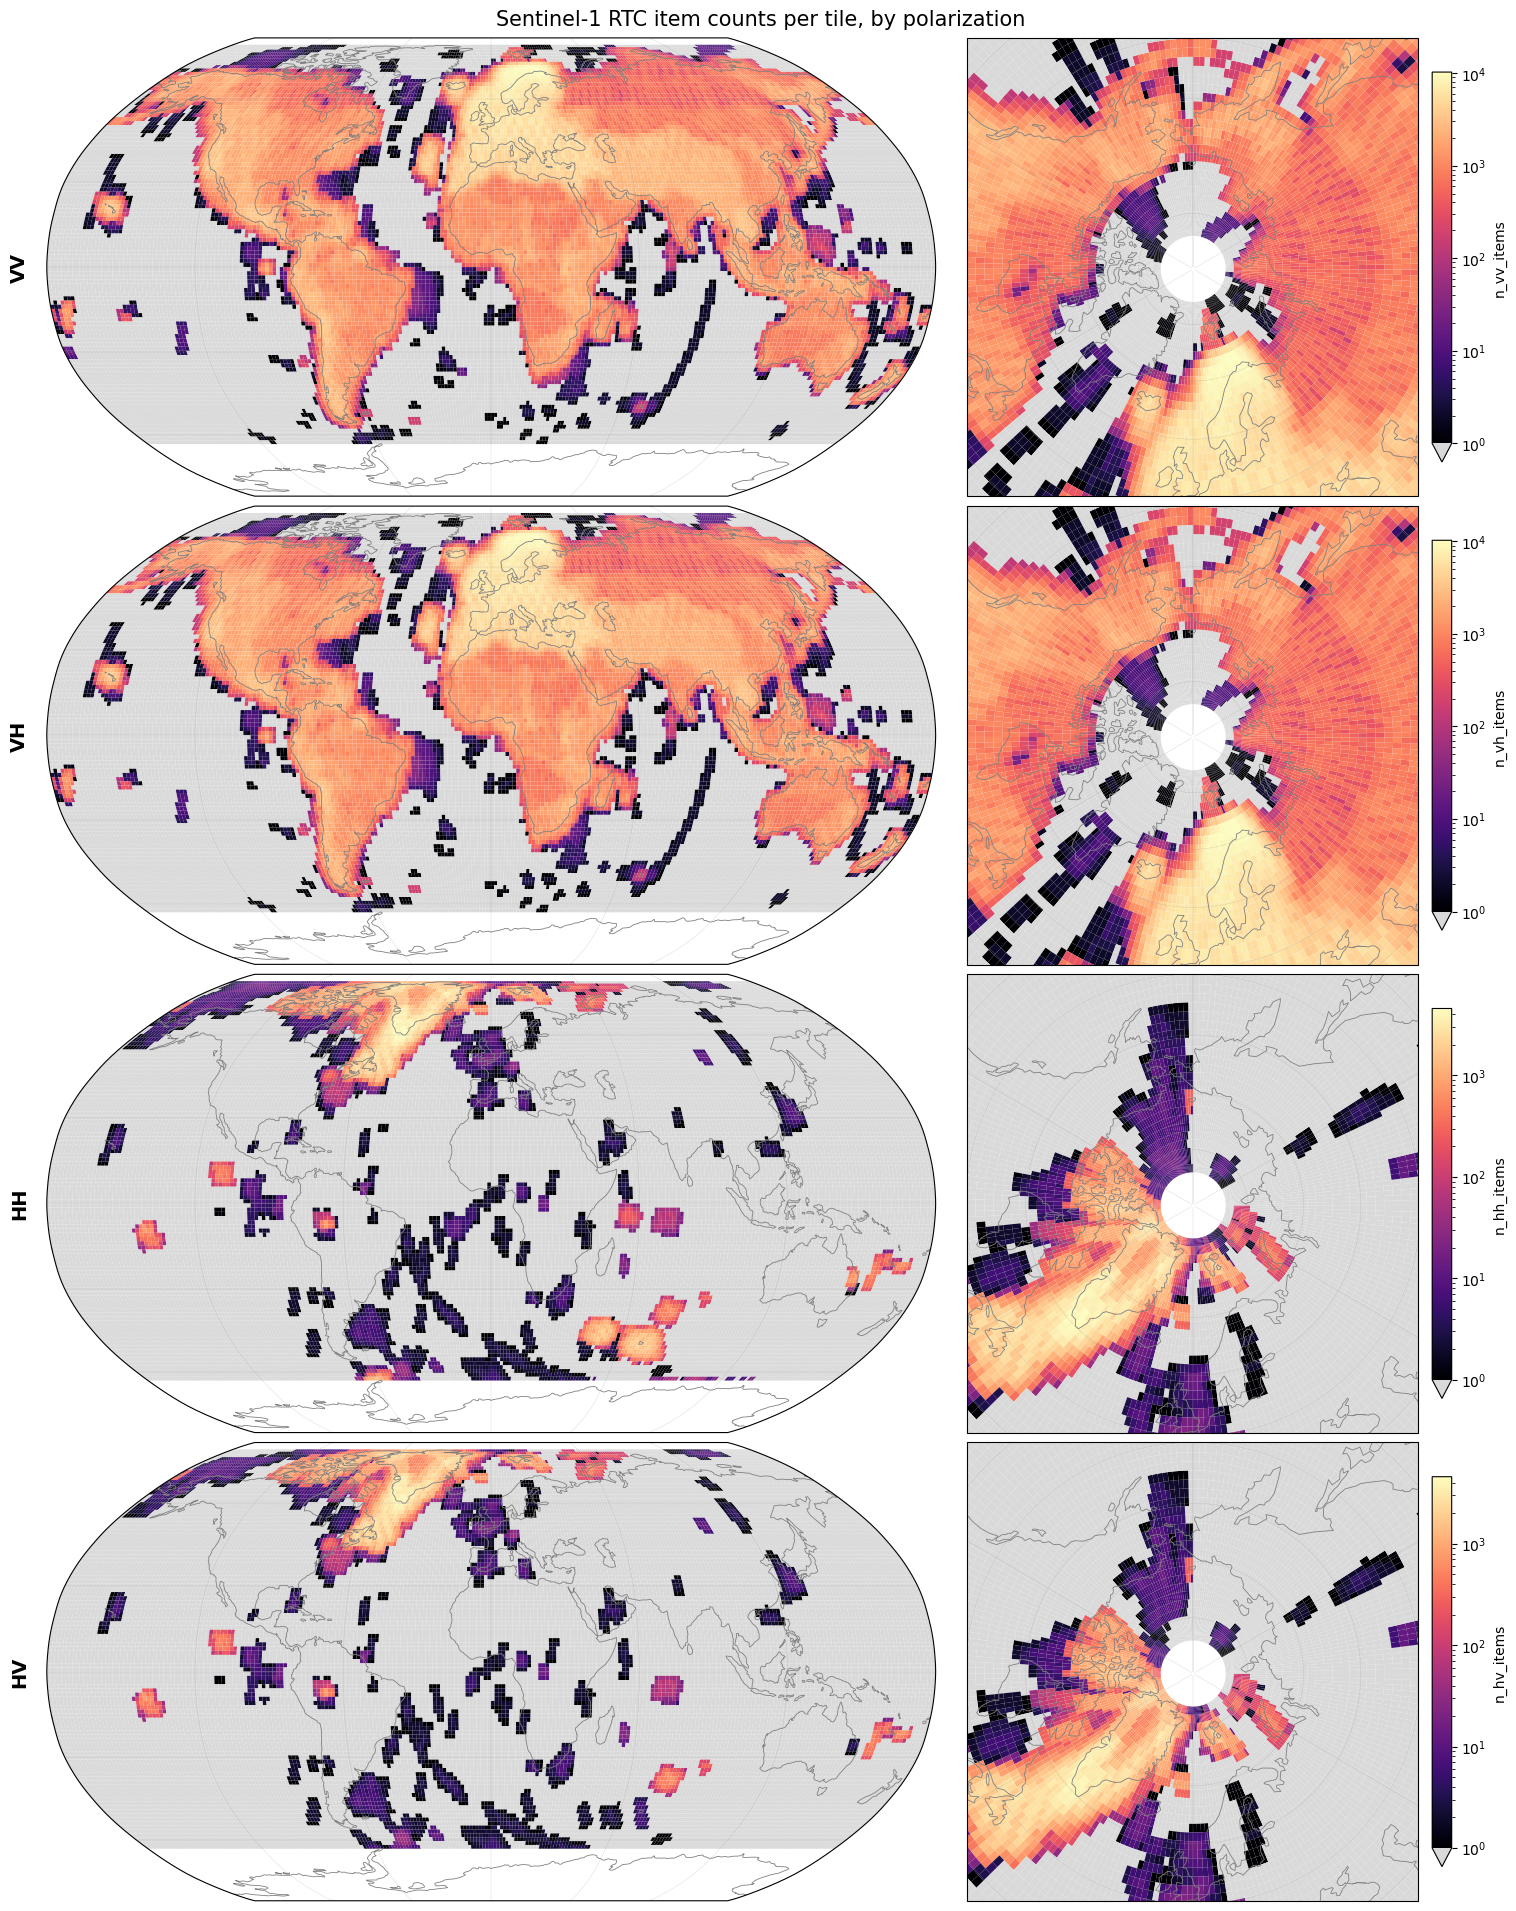

In [ ]:
# now with log scale coloring
POLARIZATION_ROWS = ["VV", "VH", "HH", "HV"]
# zero-count tiles are masked by LogNorm -> render them as flat grey
CMAP = mpl.colormaps["magma"].with_extremes(bad="0.85", under="0.85")

vmax_VV = registry_gdf[["n_vv_items", "n_vh_items"]].max().max()
vmax_HH = registry_gdf[["n_hh_items", "n_hv_items"]].max().max()

# tile corners alone project to straight chords, leaving wedge artifacts near the pole
plot_gdf = registry_gdf.assign(geometry=registry_gdf.geometry.segmentize(0.25))

fig = plt.figure(figsize=(15, 19), layout="constrained")
gs = fig.add_gridspec(len(POLARIZATION_ROWS), 2, width_ratios=[1.9, 1])

for row, pol in enumerate(POLARIZATION_ROWS):
    column = f"n_{pol.lower()}_items"
    vmax = vmax_VV if pol in ("VV", "VH") else vmax_HH
    norm = LogNorm(vmin=1, vmax=max(vmax, 2))  # one norm shared by both projections
    axs = []
    for col, proj in enumerate((ccrs.Robinson(), ccrs.NorthPolarStereo())):
        ax = fig.add_subplot(gs[row, col], projection=proj)
        if col == 0:
            ax.set_global()
        else:
            ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
        plot_gdf.plot(ax=ax, column=column, cmap=CMAP, norm=norm,
                      transform=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.6, color="0.5")
        ax.gridlines(linewidth=0.2, color="0.6", alpha=0.6)
        axs.append(ax)
    axs[0].text(-0.02, 0.5, pol, transform=axs[0].transAxes, rotation=90,
                va="center", ha="right", fontsize=14, fontweight="bold")
    sm = plt.cm.ScalarMappable(cmap=CMAP, norm=norm)
    cbar = fig.colorbar(sm, ax=axs, shrink=0.85, pad=0.01, label=column,
                        extend="min")
    cbar.ax.minorticks_on()

fig.suptitle("Sentinel-1 RTC item counts per tile, by polarization", fontsize=15)

## Decide `to_process` (and write `tile_notes`) now that every tile has all its information

A tile is processed when it has seasonal snow **and** more than `vv_item_threshold` VV items — the
count threshold rides above 0 so a handful of stray acquisitions over an otherwise uncovered tile
doesn't enter the work universe. Because no rows were dropped along the way, the snow condition
has to appear here explicitly: without it, every snow-free tile with S1 coverage (most of the
planet's land) would be selected.

`tile_notes` records which branch each tile took, so the registry explains every exclusion
instead of leaving it implied by absence.


In the future, maybe we'll use other polarizations in the pipeline (esp HH/HV for Greenland), so good to have this info now. Can always say something like must have x number of VV scenes or y number of HH scenes in order to get `to_process=True` status, etc.

In [15]:
vv_item_threshold = 40

has_seasonal_snow = registry_gdf["percent_valid_snow_pixels"] > MIN_PERCENT_SEASONAL_SNOW
enough_vv = registry_gdf["n_vv_items"] > vv_item_threshold

registry_gdf["to_process"] = has_seasonal_snow & enough_vv
registry_gdf["tile_notes"] = np.select(
    [
        has_seasonal_snow & enough_vv,
        has_seasonal_snow & (registry_gdf["n_vv_items"] > 0),
        has_seasonal_snow & (registry_gdf["n_items_total"] > 0),
        has_seasonal_snow,
    ],
    [
        "seasonal snow + IW VV data available",
        f"seasonal snow but <= {vv_item_threshold} VV items at probe date (stray acquisitions)",
        "seasonal snow; catalog has only non-VV items (e.g. IW HH/HV) at probe date",
        "seasonal snow but no S1 RTC items at probe date",
    ],
    default=f"no seasonal snow (<= {MIN_PERCENT_SEASONAL_SNOW}% of tile pixels)",
)

print(registry_gdf["tile_notes"].value_counts().to_string())
print(f"\nto_process: {int(registry_gdf['to_process'].sum())} of {len(registry_gdf)} tiles")
registry_gdf

tile_notes
no seasonal snow (<= 0.001% of tile pixels)                                   19425
seasonal snow + IW VV data available                                           4227
seasonal snow; catalog has only non-VV items (e.g. IW HH/HV) at probe date      584
seasonal snow but <= 40 VV items at probe date (stray acquisitions)             200
seasonal snow but no S1 RTC items at probe date                                  64

to_process: 4227 of 24500 tiles


tile                                           geometry  \
row col                                                                 
0   0       (0, 0)  POLYGON ((-179.99946 84.04856, -179.99946 82.5...   
    1       (0, 1)  POLYGON ((-178.5249 84.04856, -178.5249 82.574...   
    2       (0, 2)  POLYGON ((-177.05034 84.04856, -177.05034 82.5...   
    3       (0, 3)  POLYGON ((-175.57578 84.04856, -175.57578 82.5...   
    4       (0, 4)  POLYGON ((-174.10121 84.04856, -174.10121 82.5...   
...            ...                                                ...   
99  240  (99, 240)  POLYGON ((173.89529 -61.93302, 173.89529 -63.4...   
    241  (99, 241)  POLYGON ((175.36986 -61.93302, 175.36986 -63.4...   
    242  (99, 242)  POLYGON ((176.84442 -61.93302, 176.84442 -63.4...   
    243  (99, 243)  POLYGON ((178.31898 -61.93302, 178.31898 -63.4...   
    244  (99, 244)  POLYGON ((179.79354 -61.93302, 179.79354 -63.4...   

         percent_valid_snow_pixels  n_vv_items  n_vh_items  n_hh_items  \
row col                                                                  
0   0                          0.0           0           0           3   
    1                          0.0           0           0           3   
    2                          0.0           0           0           3   
    3                          0.0           0           0           3   
    4                          0.0           0           0           3   
...                            ...         ...         ...         ...   
99  240                        0.0           0           0           0   
    241                        0.0           0           0           0   
    242                        0.0           0           0           0   
    243                        0.0           0           0           0   
    244                        0.0           0           0           0   

         n_hv_items  n_items_total first_vv_date s1_probe_date  to_process  \
row col                                                                      
0   0             0              3           NaN    2026-08-03       False   
    1             0              3           NaN    2026-08-03       False   
    2             0              3           NaN    2026-08-03       False   
    3             0              3           NaN    2026-08-03       False   
    4             0              3           NaN    2026-08-03       False   
...             ...            ...           ...           ...         ...   
99  240           0              0           NaN    2026-08-03       False   
    241           0              0           NaN    2026-08-03       False   
    242           0              0           NaN    2026-08-03       False   
    243           0              0           NaN    2026-08-03       False   
    244           0              0           NaN    2026-08-03       False   

                                          tile_notes  
row col                                               
0   0    no seasonal snow (<= 0.001% of tile pixels)  
    1    no seasonal snow (<= 0.001% of tile pixels)  
    2    no seasonal snow (<= 0.001% of tile pixels)  
    3    no seasonal snow (<= 0.001% of tile pixels)  
    4    no seasonal snow (<= 0.001% of tile pixels)  
...                                              ...  
99  240  no seasonal snow (<= 0.001% of tile pixels)  
    241  no seasonal snow (<= 0.001% of tile pixels)  
    242  no seasonal snow (<= 0.001% of tile pixels)  
    243  no seasonal snow (<= 0.001% of tile pixels)  
    244  no seasonal snow (<= 0.001% of tile pixels)  

[24500 rows x 12 columns]

## View selected tiles

Text(0.5, 0.98, 'Tiles selected for processing (n_vv_items > 40)')

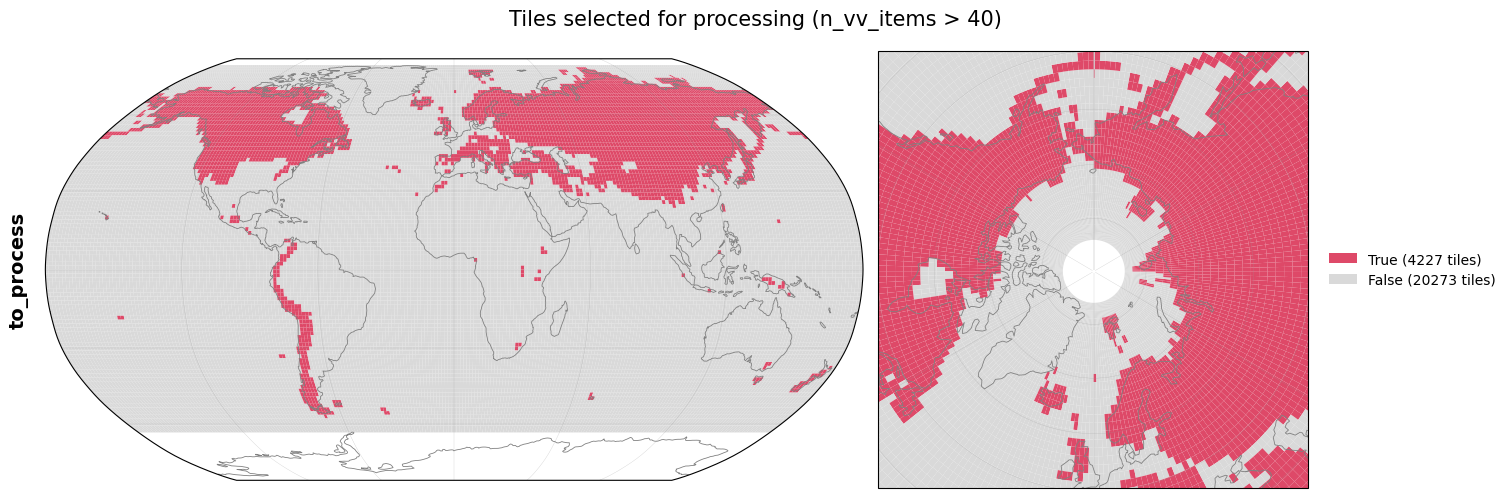

In [16]:
TO_PROCESS_COLORS = {True: plt.get_cmap(CMAP)(0.6), False: "0.85"}

plot_gdf = registry_gdf.assign(geometry=registry_gdf.geometry.segmentize(0.25))

fig = plt.figure(figsize=(15, 5), layout="constrained")
gs = fig.add_gridspec(1, 2, width_ratios=[1.9, 1])

axs = []
for col, proj in enumerate((ccrs.Robinson(), ccrs.NorthPolarStereo())):
    ax = fig.add_subplot(gs[0, col], projection=proj)
    if col == 0:
        ax.set_global()
    else:
        ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
    plot_gdf.plot(ax=ax, color=plot_gdf["to_process"].map(TO_PROCESS_COLORS),
                  transform=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.6, color="0.5")
    ax.gridlines(linewidth=0.2, color="0.6", alpha=0.6)
    axs.append(ax)
axs[0].text(-0.02, 0.5, "to_process", transform=axs[0].transAxes, rotation=90,
            va="center", ha="right", fontsize=14, fontweight="bold")

counts = plot_gdf["to_process"].value_counts()
axs[1].legend(handles=[mpatches.Patch(facecolor=TO_PROCESS_COLORS[v],
                                      label=f"{v} ({counts.get(v, 0)} tiles)")
                       for v in (True, False)],
              loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

fig.suptitle(f"Tiles selected for processing (n_vv_items > {vv_item_threshold})", fontsize=15)

In [17]:
# registry_gdf.explore(column="to_process", 
#                        legend=True, 
#                        tiles="Esri.WorldImagery",
#                        tooltip=["tile", "percent_valid_snow_pixels", "n_vv_items", "n_vh_items", "n_hh_items", "n_hv_items", "n_items_total", "first_vv_date", "s1_probe_date", "tile_notes"],
#                        )

## Output the versioned registry

**Every tile in the grid is written** — all 24,500 rows, not just the selected ones. Columns:
`percent_valid_snow_pixels`, `n_vv_items`, `n_vh_items`, `n_hh_items`, `n_hv_items`,
`n_items_total`, `first_vv_date`, `s1_probe_date`, `tile_notes`, `to_process`.

Rows with `to_process == False` stay in the file as documentation of *why* a tile is excluded —
no seasonal snow, only HH/HV coverage, too few VV items, nothing in the catalog — which is
information that vanished when earlier versions subset the frame instead.
`status.get_tile_status_gdf` filters on `to_process` to build the work universe, and the full
registry stays available for per-tile lookups via `config.valid_tiles_gdf`. Keeping every tile
takes the GeoJSON from ~2 MB to ~10 MB; pass `COORDINATE_PRECISION=6` to `to_file` to trim ~20 %
of that if the size becomes annoying.

In [18]:
registry_gdf.drop(columns=["tile"], errors="ignore").to_file(config.valid_tiles_geojson_path, driver="GeoJSON")

## Sentinel-1 input volume (manuscript Sect. 2.2.3)

Replaces the hand-waved ">100 TB of Sentinel-1 data" with a computed estimate: the total size of the
**VV IW RTC assets** (the COGs this pipeline reads from) for every unique scene whose footprint intersects
a `to_process` tile within the config's acquisition window. Scene IDs come from the same deduplicated
GeoParquet partitions as the availability scan above (**run that section first** — this reuses `dataset`
and `registry_gdf`); byte sizes come from a stratified `Content-Length` HEAD sample because the GeoParquet
does not carry asset sizes.

Two distinct volume numbers exist — this one is *"size of the source imagery touched"*. The complementary
*"bytes actually read at the 80 m overview level"* is recorded per tile x water year in the icechunk commit
stats (`stats.dest_gb`, summable in `check_tile_status.ipynb`) once the v10 fleet has run.

Writes `results/<version>/s1_input_volume.csv`.

In [ ]:
# Pass over the deduplicated partitions: unique VV items intersecting to_process tiles
# within the acquisition window (northern WY start of the first year through the
# southern-hemisphere tail of the last year).
wy_min, wy_max = min(config.water_years), max(config.water_years)
t_start = pd.Timestamp(f"{wy_min - 1}-10-01", tz="UTC")
t_end = pd.Timestamp(f"{wy_max + 1}-03-31T23:59:59", tz="UTC")

proc_tree = shapely.STRtree(registry_gdf.loc[registry_gdf["to_process"]].geometry.values)

vv_items = {}  # item id -> acquisition calendar year
vol_cols = ["id", "geometry", "datetime", "sar:polarizations"]
for frag in tqdm(list(dataset.get_fragments()), desc="collecting VV item ids"):
    tbl = frag.to_table(columns=vol_cols)
    if tbl.num_rows == 0:
        continue
    ids = tbl["id"].to_pylist()
    dts = pd.to_datetime(tbl["datetime"].to_pylist(), utc=True)
    has_vv = np.array(["VV" in (p or []) for p in tbl["sar:polarizations"].to_pylist()])
    keep = has_vv & (dts >= t_start).values & (dts <= t_end).values
    if not keep.any():
        continue
    keep_idx = np.flatnonzero(keep)
    footprints = shapely.from_wkb(tbl["geometry"].to_pylist())
    hits = proc_tree.query(footprints[keep_idx], predicate="intersects")  # (2, n): [input_i, tile_i]
    for local_i in np.unique(hits[0]):
        gi = keep_idx[local_i]
        vv_items[ids[gi]] = int(dts[gi].year)

print(f"{len(vv_items):,} unique VV IW RTC items intersect the "
      f"{int(registry_gdf['to_process'].sum()):,} to_process tiles, "
      f"{t_start.date()} .. {t_end.date()}")

In [ ]:
# Stratified size sample: HEAD the VV COG of ~400 scenes (proportional per calendar
# year), then scale mean asset size by the unique-item count. The GeoParquet has no
# file:size, so Content-Length on the signed hrefs is the ground truth.
import requests
import pystac_client

SAMPLE_N = 400
rng = np.random.default_rng(0)  # deterministic sample
ids_by_year = collections.defaultdict(list)
for iid, yr in vv_items.items():
    ids_by_year[yr].append(iid)
sample_ids = []
for yr in sorted(ids_by_year):
    ids = ids_by_year[yr]
    k = min(len(ids), max(2, round(SAMPLE_N * len(ids) / len(vv_items))))
    sample_ids += list(rng.choice(ids, size=k, replace=False))

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
sizes_by_year = collections.defaultdict(list)
BATCH = 50
for i in tqdm(range(0, len(sample_ids), BATCH), desc="HEAD-sampling VV asset sizes"):
    for item in catalog.search(collections=["sentinel-1-rtc"], ids=sample_ids[i:i + BATCH]).items():
        r = requests.head(item.assets["vv"].href, timeout=30)
        size = int(r.headers.get("Content-Length", 0))
        if size:
            sizes_by_year[item.datetime.year].append(size)

all_sizes = np.array([s for v in sizes_by_year.values() for s in v], dtype=float)
print(f"sampled {len(all_sizes)} VV assets: mean {all_sizes.mean() / 1e6:.0f} MB, "
      f"std {all_sizes.std() / 1e6:.0f} MB")

In [ ]:
# Aggregate + persist. Per-year mean sizes weight the total, so a drifting scene
# size over the mission doesn't bias the estimate; the standard error is the
# sampling uncertainty on the grand total.
from global_snowmelt_runoff_onset.results import save_result_table

rows = []
for yr in sorted(ids_by_year):
    n = len(ids_by_year[yr])
    s = np.array(sizes_by_year.get(yr, []), dtype=float)
    mean_gb = s.mean() / 1e9 if len(s) else np.nan
    rows.append({'calendar_year': yr, 'n_vv_items': n, 'n_sampled': len(s),
                 'mean_vv_asset_gb': round(mean_gb, 3) if len(s) else None,
                 'est_volume_tb': round(n * mean_gb / 1e3, 2) if len(s) else None})
per_year_df = pd.DataFrame(rows)

est_total_tb = float(per_year_df['est_volume_tb'].sum())
se_total_tb = float(all_sizes.std() / np.sqrt(len(all_sizes)) * len(vv_items) / 1e12)
total_row = pd.DataFrame([{'calendar_year': 'TOTAL', 'n_vv_items': len(vv_items),
                           'n_sampled': int(len(all_sizes)),
                           'mean_vv_asset_gb': round(all_sizes.mean() / 1e9, 3),
                           'est_volume_tb': round(est_total_tb, 1)}])
volume_df = pd.concat([per_year_df, total_row], ignore_index=True)
volume_df['se_total_tb'] = round(se_total_tb, 2)
volume_df['window'] = f"{t_start.date()}..{t_end.date()}"
volume_df['scope'] = 'unique VV IW RTC assets intersecting to_process tiles'

save_result_table(volume_df, 's1_input_volume', version=config.version, results_dir='results')
print(f"*** estimated S1 VV input volume: {est_total_tb:,.1f} +/- {se_total_tb:.1f} TB "
      f"across {len(vv_items):,} unique scenes ***")
volume_df